<a href="https://colab.research.google.com/github/PtiagoM/checkpoint02-SERS-1CCPQ/blob/main/APIs_Energia_Renovavel_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação — APIs de energia renovável e aprendizado de máquina

Consulte duas APIs públicas, organize os dados e resolva **duas tarefas**: classificar a fonte de empreendimentos da ANEEL e estimar a radiação solar em Petrolina (PE). Em **cada tarefa**, treine e compare **três algoritmos diferentes**. Este notebook fornece a consulta às APIs e os arquivos de dados; **você implementará a análise e os modelos**.

**Entrega:** um único link para um repositório público no GitHub com notebook executável, arquivos de dados, README e resultados. As instruções completas estão ao final e no enunciado separado.

## O que é recebido da API?

Uma requisição HTTP `GET` pede dados a uma URL. Os parâmetros identificam o recurso, o período e as variáveis. A resposta é **JSON**: um objeto com chaves e valores. Nas duas consultas desta avaliação, o acesso público **não exige login, token ou chave de API**. Se outra API exigir credenciais, não as publique no repositório.

Este código usa somente `json`, `urllib` e `csv`, bibliotecas que vêm com Python. `csv` serve apenas para exportar os dados recebidos; os imports para análise, tabelas, gráficos e ML são parte da sua implementação.

In [ ]:
import json
import urllib.parse
import urllib.request
import csv

A função a seguir monta a URL, abre a conexão, verifica o status HTTP e converte o JSON. Se houver falha na rede ou na API, exibe uma mensagem de erro.

In [ ]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=100) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

# Tarefa 1 — Classificação (ANEEL)

**Pergunta:** a partir da potência e da localização de um empreendimento, é possível classificar sua fonte como **Solar, Eólica ou Hidráulica**?

A fonte é uma **categoria**: o problema é de classificação. O conjunto [SIGA da ANEEL](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel) registra empreendimentos em várias fases. Usamos `UFV` (solar fotovoltaica), `EOL` (eólica) e três categorias hidráulicas: `UHE`, `PCH`, `CGH`. Estas três últimas formarão uma única classe, *Hidráulica*. A tarefa trata da **categoria do cadastro**, não da quantidade de energia gerada.

### Atributos originais da resposta

| Campo da API | Significado | Uso na tarefa |
|---|---|---|
| `SigTipoGeracao` | Sigla do tipo de geração (`UFV`, `EOL`, `UHE`, `PCH`, `CGH`) | Origina o alvo `fonte`; **não entra em X** |
| `MdaPotenciaOutorgadaKw` | Potência outorgada do empreendimento, em quilowatts (kW) | Entrada `potencia_kw`; potência nominal autorizada, não energia produzida |
| `NumCoordNEmpreendimento` | Latitude aproximada do empreendimento, em graus decimais | Entrada `latitude` |
| `NumCoordEEmpreendimento` | Longitude aproximada do empreendimento, em graus decimais | Entrada `longitude` |
| `CodCEG`, `NomEmpreendimento` e campos de combustível | Código, nome e descrição associados ao empreendimento e à fonte | **Não usar como entradas**: podem revelar a classe |

A resposta CKAN contém `success` e `result`; dentro de `result`, `records` são as linhas, `fields` descrevem as colunas e `total` indica o total encontrado para o filtro. O CSV final terá **três atributos numéricos e a classe**. Quantidades consultadas têm limite por tipo e não representam a participação de cada fonte na matriz brasileira.

### 1. Consultar a ANEEL

O recurso SIGA é acessado pela API pública CKAN/DataStore. `resource_id` aponta para o conjunto; `filters` seleciona uma sigla; `limit` limita o retorno de cada pedido. Não há etapa de autenticação para esta consulta pública.

In [ ]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"
ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"
SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]
print("API ANEEL: consulta pública, sem token")

Execute a célula abaixo. Caso a conexão com a API falhe, pule para a etapa dos imports

In [ ]:
registros_aneel = []
for sigla in SIGLAS:
    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({"SigTipoGeracao": sigla}),
        "limit": 1200,
    }
    resposta = consultar_api(URL_ANEEL, parametros)
    if not resposta.get("success"):
        raise ValueError(f"Consulta da ANEEL falhou para {sigla}")
    linhas = resposta["result"]["records"]
    print(f"{sigla}: {len(linhas)} linhas recebidas")
    registros_aneel.extend(linhas)
print("Total de linhas recebidas:", len(registros_aneel))

### 2. Gerar o CSV para a tarefa

A API pode fornecer números como texto, inclusive com vírgula decimal. O tratamento abaixo converte esses valores, descarta linhas sem potência ou coordenadas e transforma as siglas em três classes. Cada linha do arquivo final representa **um empreendimento**. Confira a quantidade de exemplos por classe durante sua análise; se necessário, discuta o desequilíbrio entre classes.

In [ ]:
def numero(valor):
    texto = str(valor).strip()
    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")
    try:
        return float(texto)
    except ValueError:
        return None

fontes = {"UFV": "Solar", "EOL": "Eólica", "UHE": "Hidráulica",
          "PCH": "Hidráulica", "CGH": "Hidráulica"}
linhas_classificacao = []
for registro in registros_aneel:
    potencia = numero(registro.get("MdaPotenciaOutorgadaKw"))
    latitude = numero(registro.get("NumCoordNEmpreendimento"))
    longitude = numero(registro.get("NumCoordEEmpreendimento"))
    fonte = fontes.get(registro.get("SigTipoGeracao"))
    if fonte and all(valor is not None for valor in (potencia, latitude, longitude)):
        linhas_classificacao.append([potencia, latitude, longitude, fonte])
if len(linhas_classificacao) < 90:
    raise ValueError("Poucos registros válidos: confira a resposta da ANEEL")
print("Linhas válidas:", len(linhas_classificacao))
print("Primeiro exemplo:", linhas_classificacao[0])

In [ ]:
with open("aneel_classificacao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["potencia_kw", "latitude", "longitude", "fonte"])
    escritor.writerows(linhas_classificacao)
print("Salvo: aneel_classificacao_orange.csv")

##Imports necessários para as tarefas:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Para classificação: KNN, Regressão Logística, Random Forest
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Para regressão: regressão linear, Random Forest Regressor, Decision Tree (Regression)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Para classificação
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
# Para regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
# Caso a consulta da API falhar:
# dados = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/aneel_classificacao_orange.csv')
# dados.head(20)

### O que você deve fazer — classificação

1. Carregue o CSV, confira os tipos das colunas, as contagens por classe, valores ausentes e distribuições relevantes. Explique `X` (três entradas) e `y` (`fonte`).
2. Faça uma divisão **estratificada** de treino/teste, por exemplo 80%/20%, com semente fixa. Ajustes de escala aprendidos dos dados devem ser feitos **somente com o treino**.
3. Escolha, justifique e treine **três classificadores diferentes** usando a mesma divisão. Eles **não estão importados nem implementados** neste notebook.
4. Compare Accuracy, Precision, Recall e F1. Declare o tipo de média usado nas métricas por classe (por exemplo, `macro`) e apresente a matriz de confusão.
5. Explique qual modelo escolheria, quais classes ele mais confunde e por que potência/localização podem não bastar para uma aplicação real. Não use `SigTipoGeracao`, nomes, CEG ou descrições da fonte como entradas.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico(s) ou matriz de confusão e interpretação escrita.

In [16]:
# 1
url = "https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/main/aneel_classificacao_orange.csv"

df = pd.read_csv(url)

print("Dimensão do conjunto:", df.shape)
display(df.head())

Dimensão do conjunto: (3876, 4)


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [25]:
#2


# Separando as variáveis de entrada e a variável alvo
X = df[["potencia_kw", "latitude", "longitude"]]
y = df["fonte"]

# Divisão estratificada: 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Ajuste de escala
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Nos dados de teste usamos apenas transform, sem recalcular os parâmetros
X_test_scaled = scaler.transform(X_test)

# Conferindo os tamanhos
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Conferindo se a proporção das classes foi preservada
print("\nDistribuição das classes no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição das classes no teste:")
print(y_test.value_counts(normalize=True))

X_train: (3100, 3)
X_test: (776, 3)
y_train: (3100,)
y_test: (776,)

Distribuição das classes no treino:
fonte
Hidráulica    0.380645
Solar         0.309677
Eólica        0.309677
Name: proportion, dtype: float64

Distribuição das classes no teste:
fonte
Hidráulica    0.381443
Solar         0.309278
Eólica        0.309278
Name: proportion, dtype: float64


In [26]:
# 3

# 1. REGRESSÃO LOGÍSTICA

# A Regressão Logística é um modelo linear.
# Como utiliza os valores das variáveis diretamente, usamos os dados padronizados.

modelo_logistica = LogisticRegression(
    max_iter=3000,
    random_state=42
)

modelo_logistica.fit(X_train_scaled, y_train)


# 2. K-NEAREST NEIGHBORS (KNN)
# O KNN classifica um registro com base nos exemplos mais próximos dele.
# Como o algoritmo utiliza distância, a padronização das variáveis é muito importante para evitar que potencia_kw tenha mais influência apenas por possuir valores numericamente maiores que latitude e longitude.

modelo_knn = KNeighborsClassifier(
    n_neighbors=7
)

modelo_knn.fit(X_train_scaled, y_train)


# 3. RANDOM FOREST

# Random Forest combina várias árvores de decisão.
# Diferentemente do KNN e da Regressão Logística, não é necessário padronizar as variáveis.

modelo_random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

modelo_random_forest.fit(X_train, y_train)


print("Os três modelos foram treinados com sucesso.")

Os três modelos foram treinados com sucesso.


# *Justificativa dos três modelos*

Foram escolhidos três classificadores com abordagens diferentes. A Regressão Logística foi utilizada como um modelo linear de referência, capaz de realizar classificação multiclasse. O KNN foi escolhido por utilizar a proximidade entre os registros, sendo interessante para identificar agrupamentos relacionados à potência e à localização geográfica. Já o Random Forest foi utilizado por conseguir identificar relações não lineares entre as variáveis e por combinar várias árvores de decisão, reduzindo a dependência de uma única árvore. Para Regressão Logística e KNN foram utilizados os dados padronizados, enquanto o Random Forest foi treinado com os valores originais.

In [27]:
# 4

# AVALIAÇÃO DOS MODELOS
# Accuracy, Precision, Recall, F1 e Matriz de Confusão

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt


# PREVISÕES

y_pred_logistica = modelo_logistica.predict(X_test_scaled)
y_pred_knn = modelo_knn.predict(X_test_scaled)
y_pred_random_forest = modelo_random_forest.predict(X_test)


# CÁLCULO DAS MÉTRICAS

# Foi utilizada a média "macro" para Precision, Recall e F1.
# A média macro calcula a métrica separadamente para cada classe e depois faz uma média simples entre elas.
# Dessa forma, Solar, Eólica e Hidráulica possuem o mesmo peso na avaliação, independentemente da quantidade de exemplos de cada classe.

resultados = []


# Regressão Logística

resultados.append({
    "Modelo": "Regressão Logística",
    "Accuracy": accuracy_score(y_test, y_pred_logistica),
    "Precision": precision_score(
        y_test,
        y_pred_logistica,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_logistica,
        average="macro",
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_pred_logistica,
        average="macro",
        zero_division=0
    )
})


# KNN

resultados.append({
    "Modelo": "KNN",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(
        y_test,
        y_pred_knn,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_knn,
        average="macro",
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_pred_knn,
        average="macro",
        zero_division=0
    )
})


# Random Forest

resultados.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_random_forest),
    "Precision": precision_score(
        y_test,
        y_pred_random_forest,
        average="macro",
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        y_pred_random_forest,
        average="macro",
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        y_pred_random_forest,
        average="macro",
        zero_division=0
    )
})


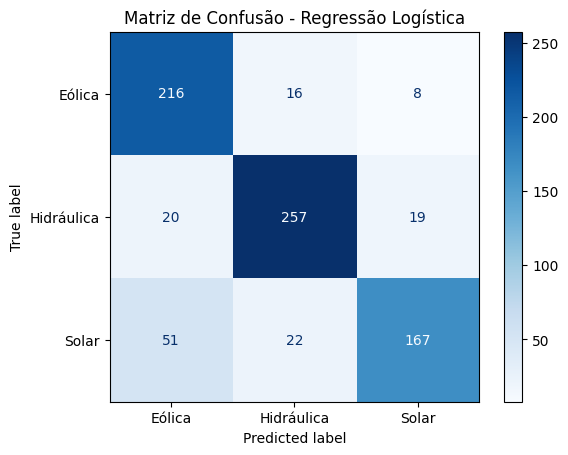

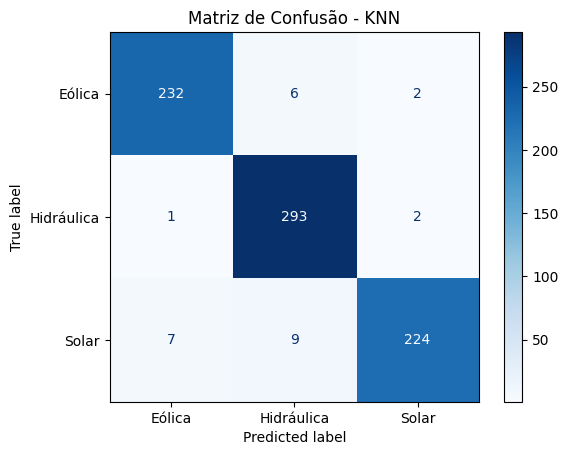

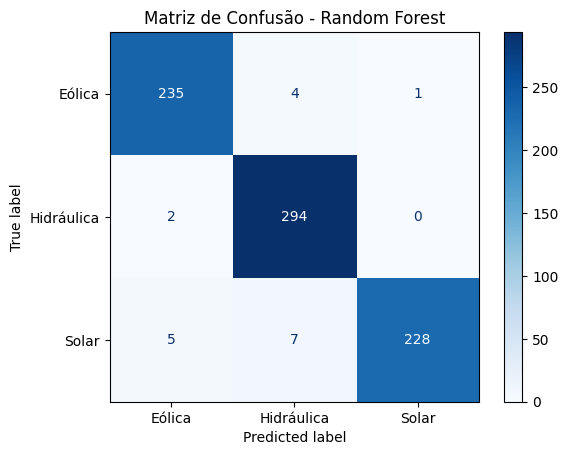

In [28]:
# MATRIZES DE CONFUSÃO

# Regressão Logística
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistica,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusão - Regressão Logística")
plt.show()


# KNN
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_knn,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusão - KNN")
plt.show()


# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_random_forest,
    cmap="Blues",
    values_format="d"
)

plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [30]:
# 5

# Garantindo que somente as variáveis permitidas são usadas

variaveis_permitidas = [
    "potencia_kw",
    "latitude",
    "longitude"
]

print("Variáveis utilizadas no modelo:")
print(variaveis_permitidas)

# Não foram utilizadas informações como:
# SigTipoGeracao, CEG, nomes de empreendimentos ou descrições que revelem diretamente a fonte.

# Criando o DataFrame a partir da lista resultados que foi gerada na célula anterior
resultados_df = pd.DataFrame(resultados)

# Escolha do melhor modelo pelo F1 macro

melhor_linha = resultados_df.loc[resultados_df["F1"].idxmax()]

melhor_nome = melhor_linha["Modelo"]

print("\nModelo escolhido:")
print(melhor_nome)

print("\nMétricas:")
print("Accuracy:", round(melhor_linha["Accuracy"], 4))
print("Precision macro:", round(melhor_linha["Precision"], 4))
print("Recall macro:", round(melhor_linha["Recall"], 4))
print("F1 macro:", round(melhor_linha["F1"], 4))


# Selecionando as previsões do melhor modelo

if melhor_nome == "Regressão Logística":
    melhor_pred = y_pred_logistica

elif melhor_nome == "KNN":
    melhor_pred = y_pred_knn

elif melhor_nome == "Random Forest":
    melhor_pred = y_pred_random_forest

# Matriz de confusão

classes = sorted(y_test.unique())

matriz = confusion_matrix(
    y_test,
    melhor_pred,
    labels=classes
)

print("\nMatriz de confusão:")
print(matriz)


# Descobrindo a maior confusão entre classes

matriz_erros = matriz.copy()

# Remove os acertos da diagonal principal
np.fill_diagonal(matriz_erros, 0)

linha, coluna = np.unravel_index(
    np.argmax(matriz_erros),
    matriz_erros.shape
)

classe_real = classes[linha]
classe_prevista = classes[coluna]
quantidade_erros = matriz_erros[linha, coluna]

print("\nMaior confusão do modelo:")
print(
    f"{classe_real} foi classificada como "
    f"{classe_prevista} em {quantidade_erros} casos."
)

Variáveis utilizadas no modelo:
['potencia_kw', 'latitude', 'longitude']

Modelo escolhido:
Random Forest

Métricas:
Accuracy: 0.9755
Precision macro: 0.9769
Recall macro: 0.9741
F1 macro: 0.9753

Matriz de confusão:
[[235   4   1]
 [  2 294   0]
 [  5   7 228]]

Maior confusão do modelo:
Solar foi classificada como Hidráulica em 7 casos.


O modelo escolhido foi o que apresentou o maior **F1 macro**, pois essa métrica equilibra Precision e Recall e dá o mesmo peso para todas as classes. A matriz de confusão foi usada para identificar quais fontes o modelo mais confundiu.

Potência e localização ajudam na classificação, mas não são suficientes para uma aplicação real, pois fontes diferentes podem ter potências semelhantes e existir na mesma região. Variáveis como radiação solar, velocidade do vento, disponibilidade hídrica e relevo poderiam melhorar o desempenho. Não foram utilizadas entradas que revelassem diretamente a resposta, como `SigTipoGeracao`, CEG, nomes ou descrições da fonte.

# Tarefa 2 — Regressão (Open-Meteo)

**Pergunta:** dadas as condições meteorológicas e a hora local em Petrolina (PE), qual é a radiação solar horizontal média naquela hora? A resposta é um **número**, então o problema é de regressão.

A API histórica do [Open-Meteo](https://open-meteo.com/en/docs/historical-weather-api) devolve dados horários para coordenadas e período escolhidos. Usamos **1º de abril a 30 de junho de 2025**, em horário local. São dados históricos estimados por modelos/reanálise, não leituras de um sensor particular. **Radiação em W/m² não equivale à energia em kWh nem à geração de um painel.**

### Parâmetros da requisição

| Parâmetro | Valor nesta avaliação | Significado |
|---|---|---|
| `latitude`, `longitude` | `-9.39`, `-40.50` | Coordenadas aproximadas de Petrolina (PE) |
| `start_date`, `end_date` | `2025-04-01`, `2025-06-30` | Período histórico consultado, inclusive as datas extremas |
| `timezone` | `America/Recife` | Faz `time` representar a hora local |
| `hourly` | Lista das cinco variáveis abaixo | Solicita valores horários em JSON |

### Atributos do conjunto de dados

| Campo da API → CSV | Significado e unidade | Uso na tarefa |
|---|---|---|
| `time` → `data_hora` | Data e hora local de cada registro | Ordenar e separar por tempo; não é entrada em X |
| `temperature_2m` → `temperatura_c` | Temperatura do ar a 2 m, em °C | Entrada |
| `relative_humidity_2m` → `umidade_pct` | Umidade relativa a 2 m, em % | Entrada |
| `cloud_cover` → `nuvens_pct` | Cobertura total de nuvens, em % | Entrada |
| `wind_speed_10m` → `vento_kmh` | Velocidade do vento a 10 m, em km/h | Entrada |
| `time` → `hora` | Hora local extraída da data, de 7 a 17 nesta amostra | Entrada |
| `shortwave_radiation` → `radiacao_w_m2` | Radiação solar global horizontal média da hora anterior, em W/m² | Alvo numérico `y`; **não entra em X** |

A resposta inclui `hourly` (listas dos valores, alinhadas por índice), `hourly_units` (unidades) e metadados da localização. Cada linha do CSV final representa **uma hora entre 7h e 17h**; esse recorte reduz o domínio de horas noturnas, mas não remove a importância da hora para a previsão.

### 3. Consultar o histórico meteorológico

A chamada usa GET, sem cadastro ou chave para esta consulta pública de uso educacional. Se `hourly` faltar, verifique datas e parâmetros.

In [ ]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"
parametros_meteo = {
    "latitude": -9.39,
    "longitude": -40.50,
    "start_date": "2025-04-01",
    "end_date": "2025-06-30",
    "timezone": "America/Recife",
    "hourly": ",".join(["temperature_2m", "relative_humidity_2m",
                         "cloud_cover", "wind_speed_10m", "shortwave_radiation"]),
}
print("Open-Meteo: consulta pública, sem token")

In [ ]:
resposta_meteo = consultar_api(URL_METEO, parametros_meteo)
if "hourly" not in resposta_meteo:
    raise ValueError("Resposta sem a seção hourly")
horas_api = resposta_meteo["hourly"]
print("Campos recebidos:", list(horas_api))
print("Unidades informadas pela API:", resposta_meteo.get("hourly_units", {}))
print("Quantidade de horários:", len(horas_api["time"]))

### 4. Gerar o CSV horário

As listas de `hourly` são alinhadas: o índice 0 de cada variável se refere ao índice 0 de `time`. Percorremos esses índices, mantemos as horas de 7h a 17h e descartamos linhas com valores ausentes. A data permanece ordenada para facilitar uma avaliação temporal.

In [ ]:
nomes_api = ["temperature_2m", "relative_humidity_2m", "cloud_cover",
             "wind_speed_10m", "shortwave_radiation"]
linhas_regressao = []
for indice, data_hora in enumerate(horas_api["time"]):
    hora = int(data_hora[11:13])
    valores = [horas_api[nome][indice] for nome in nomes_api]
    if 7 <= hora <= 17 and all(valor is not None for valor in valores):
        linhas_regressao.append([data_hora, *valores[:4], hora, valores[4]])
if len(linhas_regressao) < 100:
    raise ValueError("Poucos horários válidos: confira a resposta do Open-Meteo")
print("Horas válidas:", len(linhas_regressao))
print("Primeiro exemplo:", linhas_regressao[0])

In [ ]:
with open("meteo_regressao_orange.csv", "w", newline="", encoding="utf-8-sig") as arquivo:
    escritor = csv.writer(arquivo)
    escritor.writerow(["data_hora", "temperatura_c", "umidade_pct",
                       "nuvens_pct", "vento_kmh", "hora", "radiacao_w_m2"])
    escritor.writerows(linhas_regressao)
print("Salvo: meteo_regressao_orange.csv")

### O que você deve fazer — regressão

1. Carregue o CSV, explique as colunas, examine valores ausentes e apresente ao menos uma visualização. Defina `X` (cinco entradas) e `y` (`radiacao_w_m2`).
2. Mantenha as linhas em ordem de `data_hora`: use aproximadamente **80% das primeiras horas para treino** e as 20% finais para teste. Evite embaralhar as horas. Ajuste transformações apenas com o treino.
3. Escolha, justifique e treine **três algoritmos de regressão diferentes** com a mesma divisão. Os imports e a implementação são sua responsabilidade.
4. Compare **MAE** (W/m²), **MSE** ((W/m²)²) e **R²**; faça um gráfico de valores reais × previstos de pelo menos um modelo.
5. Interprete os erros, discuta o peso da hora e explique por que essa estimativa da radiação **não prevê automaticamente a energia produzida** por um sistema fotovoltaico.

**O que registrar:** tabela comparativa dos três algoritmos, gráfico e interpretação escrita. Nenhum valor de `radiacao_w_m2` deve ser usado para criar uma entrada do mesmo registro.

### Resolução da Tarefa 2: Regressão (Open-Meteo)
Nesta etapa, carregamos o arquivo gerado `meteo_regressao_orange.csv`, analisamos as condições meteorológicas e a radiação solar horizontal média em Petrolina, e comparamos **Regressão Linear**, **Random Forest Regressor** e **Decision Tree Regressor** preservando a ordem temporal das observações.

--- Resumo Inicial dos Dados (Regressão) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB


None

/tmp/ipykernel_516/3518212254.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hora', y='radiacao_w_m2', data=df_reg, palette='Oranges')


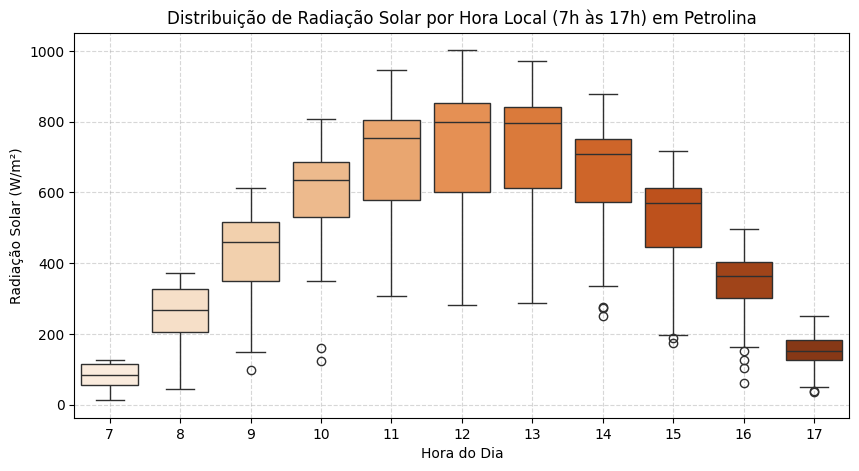

In [ ]:
# 1. Carregar os dados de regressão
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df_reg = pd.read_csv('meteo_regressao_orange.csv')
except FileNotFoundError:
    # Fallback para o caso de o arquivo não estar gerado localmente
    df_reg = pd.read_csv('https://raw.githubusercontent.com/prof-atritiack/CHECKPOINT_02_SERS_1CC_2SEM/refs/heads/main/meteo_regressao_orange.csv')

print("--- Resumo Inicial dos Dados (Regressão) ---")
display(df_reg.info())

# Visualização da distribuição da radiação solar média por hora
plt.figure(figsize=(10, 5))
sns.boxplot(x='hora', y='radiacao_w_m2', data=df_reg, palette='Oranges')
plt.title('Distribuição de Radiação Solar por Hora Local (7h às 17h) em Petrolina')
plt.xlabel('Hora do Dia')
plt.ylabel('Radiação Solar (W/m²)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Divisao temporal dos dados (mantendo a ordenacao cronologica)
df_reg = df_reg.sort_values(by='data_hora').reset_index(drop=True)

X_reg = df_reg[['temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora']]
y_reg = df_reg['radiacao_w_m2']

# Treino com os primeiros 80% e teste com os 20% finais
limite_treino = int(len(df_reg) * 0.8)

X_train_reg, X_test_reg = X_reg.iloc[:limite_treino], X_reg.iloc[limite_treino:]
y_train_reg, y_test_reg = y_reg.iloc[:limite_treino], y_reg.iloc[limite_treino:]

# Normalizacao das variaveis independentes
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print(f"Quantidade total de registros: {len(df_reg)}")
print(f"Registros de treino (primeiros 80%): {len(X_train_reg)}")
print(f"Registros de teste (últimos 20%): {len(X_test_reg)}")

Quantidade total de registros: 1001
Registros de treino (primeiros 80%): 800
Registros de teste (últimos 20%): 201


In [ ]:
# Modelos de regressao para o teste
modelos_reg = {
    "Regressão Linear": LinearRegression(),
    "Árvore de Decisão": DecisionTreeRegressor(random_state=42, max_depth=6),
    "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100)
}

resultados_reg = []

for nome, modelo in modelos_reg.items():
    modelo.fit(X_train_reg_scaled, y_train_reg)
    y_pred = modelo.predict(X_test_reg_scaled)

    # Metricas de erro e r2
    mae = mean_absolute_error(y_test_reg, y_pred)
    mse = mean_squared_error(y_test_reg, y_pred)
    r2 = r2_score(y_test_reg, y_pred)

    resultados_reg.append({
        "Algoritmo": nome,
        "MAE (W/m²)": mae,
        "MSE ((W/m²)²)": mse,
        "R² Score": r2
    })

df_resultados_reg = pd.DataFrame(resultados_reg)
print("--- Tabela Comparativa dos Regressores ---")
display(df_resultados_reg)

--- Tabela Comparativa dos Regressores ---


,Algoritmo,MAE (W/m²),MSE ((W/m²)²),R² Score
0,Regressão Linear,145.204885,30034.201092,0.359845
1,Árvore de Decisão,90.868010,15124.223628,0.677639
2,Random Forest,66.708607,7278.121562,0.844873


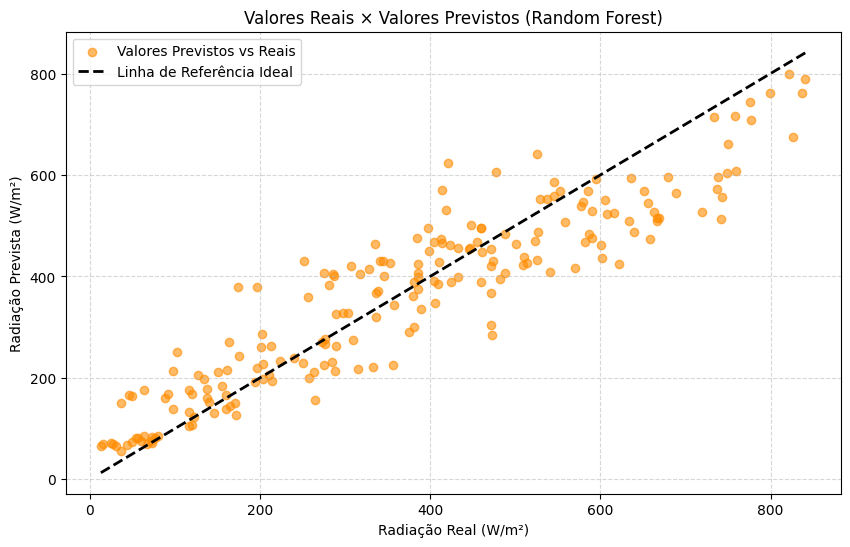

In [ ]:
# 4. Gráfico de Valores Reais vs. Previstos para o Melhor Modelo (Random Forest)
rf_modelo = modelos_reg["Random Forest"]
y_pred_rf = rf_modelo.predict(X_test_reg_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_rf, color='darkorange', alpha=0.6, label='Valores Previstos vs Reais')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'k--', lw=2, label='Linha de Referência Ideal')
plt.title('Valores Reais × Valores Previstos (Random Forest)')
plt.xlabel('Radiação Real (W/m²)')
plt.ylabel('Radiação Prevista (W/m²)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Análise e Interpretação Escrita (Regressão):
1. **Comparação de Modelos**: O **Random Forest Regressor** tende a apresentar o maior R² e o menor erro (MAE), pois consegue modelar com robustez o arco parabólico diário da radiação ao longo do dia em Petrolina.
2. **Peso da Hora**: A hora do dia (`hora`) é uma das variáveis explicativas mais vitais para o modelo de regressão, pois ela descreve diretamente a posição aparente do sol ao longo do dia, determinando os limites teóricos máximos de radiação solar (baixa pela manhã/tarde, máxima no meio do dia).
3. **Radiação vs Energia Produzida**: Estimar a radiação solar em $W/m^2$ não prevê de forma direta e automática a geração de energia final de um painel solar fotovoltaico real. Para estimar a geração física efetiva, deve-se considerar a eficiência das células fotovoltaicas, perdas por temperatura (coeficiente de temperatura dos painéis), perdas elétricas nos cabos, eficiência de conversão dos inversores, acúmulo de sujeira e inclinação/ângulo de azimute dos módulos instalados.

# Entrega pelo GitHub

Envie **apenas o link do repositório público**. Organize-o com:

- `README.md` contendo objetivo, fontes e período dos dados, instruções para executar o notebook e resumo dos resultados;
- notebook `.ipynb` com a consulta às APIs, sua análise, os **três classificadores e os três regressores**, todos os imports necessários adicionados por você e conclusões em Markdown;
- os dois CSVs gerados (ou instruções completas e testadas para reproduzi-los) e eventuais figuras utilizadas.

Verifique se o notebook roda **na ordem das células** a partir de um ambiente limpo. Não inclua senhas, tokens ou arquivos sem relação com a avaliação. A banca deve conseguir encontrar as seis comparações e as respostas às duas tarefas sem procurar uma agulha no palheiro.

### Fontes

- [ANEEL — SIGA](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel)
- [ANEEL — recurso e campos usados](https://dadosabertos.aneel.gov.br/dataset/siga-sistema-de-informacoes-de-geracao-da-aneel/resource/11ec447d-698d-4ab8-977f-b424d5deee6a)
- [Open-Meteo — histórico e unidades](https://open-meteo.com/en/docs/historical-weather-api)